# Terceiro Trabalho — Reconhecimento de Padrões

Notebook do **terceiro** trabalho: classificação de risco de crédito com o banco **Statlog (German Credit Data)**.

Nesta primeira etapa tratamos do **pré-processamento**, seguindo os tópicos da aula (*Pré-processamento e Avaliação de Classificadores*):

1. Caracterização do conjunto de dados ($n$ instâncias, $l$ parâmetros)
2. Limpeza (valores faltantes e inconsistências)
3. Análise do **desbalanceamento** entre classes
4. Codificação de atributos categóricos
5. **Normalização** (padronização $z$-score)

Implementamos **MQ**, **kNN** e **Rede MLP** com validação cruzada estratificada e as métricas da aula. Faltam SVM, AdaBoost e Random Forest.

**Dependências:** `numpy`, `pandas`, `matplotlib`, `scikit-learn`


## 1 — Configuração e caminhos

Carregamos a versão **original** do banco (`german.data`), com atributos categóricos simbólicos e numéricos, para aplicar o pré-processamento de forma explícita. A documentação local está em `documents/trabalho3/german_credit_data/german.doc`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Caminhos (notebook em Bayes/)
ROOT = Path("..").resolve()
DATA_PATH = ROOT / "documents" / "trabalho3" / "german_credit_data" / "german.data"
FIG_DIR = ROOT / "documents" / "trabalho3" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


## 2 — Carregamento dos dados

O arquivo `german.data` contém **1000** linhas. Cada linha descreve um pedido de crédito com **20 atributos** e o rótulo da classe no final:

| Classe | Significado |
|--------|-------------|
| 1 | *Good* — bom pagador |
| 2 | *Bad* — mau pagador |

Conforme a caracterização da aula, o conjunto pode ser visto como uma matriz $\mathbf{X} \in \mathbb{R}^{n \times l}$, com $n$ instâncias e $l$ parâmetros.


In [2]:
# Nomes das colunas (atributos 1–20 + classe), conforme german.doc / UCI
COLUMN_NAMES = [
    "checking_status",      # 1  - qualitativo
    "duration",             # 2  - meses
    "credit_history",       # 3  - qualitativo
    "purpose",              # 4  - qualitativo
    "credit_amount",        # 5  - numérico
    "savings_status",       # 6  - qualitativo
    "employment",           # 7  - qualitativo
    "installment_rate",     # 8  - % da renda
    "personal_status",      # 9  - qualitativo
    "other_parties",        # 10 - qualitativo
    "residence_since",      # 11 - anos
    "property_magnitude",   # 12 - qualitativo
    "age",                  # 13 - anos
    "other_payment_plans",  # 14 - qualitativo
    "housing",              # 15 - qualitativo
    "existing_credits",     # 16 - quantidade
    "job",                  # 17 - qualitativo
    "num_dependents",       # 18 - quantidade
    "own_telephone",        # 19 - qualitativo
    "foreign_worker",       # 20 - qualitativo
    "class",                # rótulo: 1=good, 2=bad
]

CATEGORICAL_COLS = [
    "checking_status", "credit_history", "purpose", "savings_status",
    "employment", "personal_status", "other_parties", "property_magnitude",
    "other_payment_plans", "housing", "job", "own_telephone", "foreign_worker",
]
NUMERIC_COLS = [
    "duration", "credit_amount", "installment_rate", "residence_since",
    "age", "existing_credits", "num_dependents",
]

df = pd.read_csv(DATA_PATH, sep=r"\s+", header=None, names=COLUMN_NAMES)
df.head()


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_rate,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


## 3 — Caracterização: dimensão e tipos

Verificamos $n$, $l$ e a relação $n/l$, relevante para a **maldição da dimensionalidade** discutida em aula: quanto maior $l$, mais instâncias tendem a ser necessárias para generalizar bem.


In [3]:
n_instances, n_cols = df.shape
n_params = n_cols - 1  # exclui a classe

print(f"n (instâncias)     = {n_instances}")
print(f"l (parâmetros)     = {n_params}")
print(f"relação n/l        = {n_instances / n_params:.1f}")
print()
print("Tipos inferidos:")
print(df.dtypes)
print()
print("Estatísticas descritivas (colunas numéricas):")
df[NUMERIC_COLS].describe().round(2)


n (instâncias)     = 1000
l (parâmetros)     = 20
relação n/l        = 50.0

Tipos inferidos:
checking_status        object
duration                int64
credit_history         object
purpose                object
credit_amount           int64
savings_status         object
employment             object
installment_rate        int64
personal_status        object
other_parties          object
residence_since         int64
property_magnitude     object
age                     int64
other_payment_plans    object
housing                object
existing_credits        int64
job                    object
num_dependents          int64
own_telephone          object
foreign_worker         object
class                   int64
dtype: object

Estatísticas descritivas (colunas numéricas):


,duration,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,20.90,3271.26,2.97,2.84,35.55,1.41,1.16
std,12.06,2822.74,1.12,1.10,11.38,0.58,0.36
min,4.00,250.00,1.00,1.00,19.00,1.00,1.00
25%,12.00,1365.50,2.00,2.00,27.00,1.00,1.00
50%,18.00,2319.50,3.00,3.00,33.00,1.00,1.00
75%,24.00,3972.25,4.00,4.00,42.00,2.00,1.00
max,72.00,18424.00,4.00,4.00,75.00,4.00,2.00


## 4 — Limpeza: dados faltantes

A aula lista três abordagens principais para dados incompletos: remover instâncias, imputar (média/moda/mediana) ou usar um valor simbólico de *desconhecido*. Verificamos se há valores ausentes neste banco.


In [4]:
missing = df.isna().sum()
print("Valores ausentes por coluna:")
print(missing[missing > 0] if missing.any() else "Nenhum valor ausente.")

# Alguns códigos categóricos usam '?' em outras bases UCI; conferimos
question_marks = (df.astype(str) == "?").sum()
print()
print("Marcadores '?' por coluna:")
print(question_marks[question_marks > 0] if question_marks.any() else "Nenhum marcador '?' encontrado.")


Valores ausentes por coluna:
Nenhum valor ausente.

Marcadores '?' por coluna:
Nenhum marcador '?' encontrado.


## 5 — Limpeza: dados inconsistentes

Dados inconsistentes violam relações esperadas entre atributos. Em bases pequenas como esta ($n=1000$), a verificação pode ser manual ou por regras simples. Aqui fazemos checagens básicas de domínio nas colunas numéricas.


In [5]:
checks = {
    "duration > 0": (df["duration"] > 0).all(),
    "credit_amount > 0": (df["credit_amount"] > 0).all(),
    "installment_rate em [1, 4]": df["installment_rate"].between(1, 4).all(),
    "age >= 18": (df["age"] >= 18).all(),
    "existing_credits >= 1": (df["existing_credits"] >= 1).all(),
    "num_dependents >= 1": (df["num_dependents"] >= 1).all(),
    "class em {1, 2}": df["class"].isin([1, 2]).all(),
}

for rule, ok in checks.items():
    status = "OK" if ok else "FALHOU"
    print(f"[{status}] {rule}")

print()
print("Valores únicos da classe:", sorted(df["class"].unique()))


[OK] duration > 0
[OK] credit_amount > 0
[OK] installment_rate em [1, 4]
[OK] age >= 18
[OK] existing_credits >= 1
[OK] num_dependents >= 1
[OK] class em {1, 2}

Valores únicos da classe: [np.int64(1), np.int64(2)]


## 6 — Desbalanceamento de classes

Em problemas reais as classes costumam ter tamanhos diferentes. O German Credit Data é **desbalanceado** (~70% *good*, ~30% *bad*). A aula menciona reamostragem, custos por classe e métricas adequadas; por ora **apenas analisamos** a distribuição — a estratégia de compensação será definida na etapa de avaliação.


In [6]:
class_counts = df["class"].value_counts().sort_index()
class_pct = (class_counts / len(df) * 100).round(1)

summary = pd.DataFrame({
    "classe": ["1 — good", "2 — bad"],
    "contagem": class_counts.values,
    "percentual (%)": class_pct.values,
})
summary


,classe,contagem,percentual (%)
0,1 — good,700,70.0
1,2 — bad,300,30.0


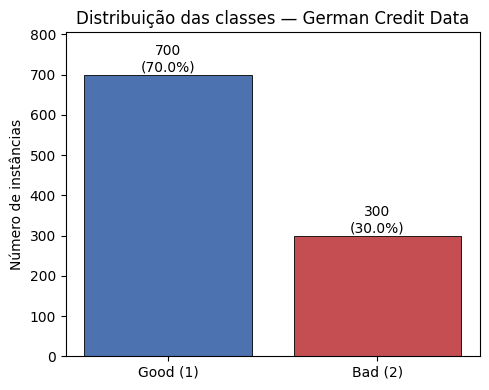

Figura salva em: C:\Users\DELL\Documents\GitHub\PatternRecognition\documents\trabalho3\figures\preproc_distribuicao_classes.png


In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
labels = ["Good (1)", "Bad (2)"]
colors = ["#4c72b0", "#c44e52"]
ax.bar(labels, class_counts.values, color=colors, edgecolor="black", linewidth=0.6)
for i, (cnt, pct) in enumerate(zip(class_counts.values, class_pct.values)):
    ax.text(i, cnt + 8, f"{cnt}\n({pct}%)", ha="center", fontsize=10)
ax.set_ylabel("Número de instâncias")
ax.set_title("Distribuição das classes — German Credit Data")
ax.set_ylim(0, class_counts.max() * 1.15)
fig.tight_layout()

fig_path = FIG_DIR / "preproc_distribuicao_classes.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print(f"Figura salva em: {fig_path}")


## 7 — Separação de atributos e rótulos

Separamos a matriz de parâmetros $\mathbf{X}$ e o vetor de classes $\mathbf{y}$.

Para os classificadores do `scikit-learn`, mapeamos **good $\rightarrow 0$** e **bad $\rightarrow 1$** (convenção binária). O rótulo original permanece em `y_raw`.


In [8]:
X_raw = df.drop(columns="class")
y_raw = df["class"].copy()

# 1=good -> 0, 2=bad -> 1
y = (y_raw - 1).astype(int)

print("X_raw:", X_raw.shape)
print("y:", y.shape)
print("Distribuição após mapeamento (0=good, 1=bad):")
print(y.value_counts().sort_index())


X_raw: (1000, 20)
y: (1000,)
Distribuição após mapeamento (0=good, 1=bad):
class
0    700
1    300
Name: count, dtype: int64


## 8 — Codificação de variáveis categóricas

Dos 20 atributos de entrada, **13 são categóricos** e **7 são numéricos** (`german.doc`). Algoritmos como kNN, SVM e MLP exigem representação numérica.

Aplicamos **one-hot encoding** às colunas categóricas com `ColumnTransformer`, mantendo as numéricas sem transformação neste passo (a normalização vem a seguir).


In [9]:
preprocess_encode = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_COLS),
        ("num", "passthrough", NUMERIC_COLS),
    ],
    verbose_feature_names_out=False,
)

X_encoded = preprocess_encode.fit_transform(X_raw)
feature_names = preprocess_encode.get_feature_names_out()

print(f"Dimensão após codificação: {X_encoded.shape[1]} parâmetros")
print(f"(original l={len(NUMERIC_COLS) + len(CATEGORICAL_COLS)} -> expandido por one-hot)")
print()
print("Primeiros 10 nomes de atributos:", list(feature_names[:10]))


Dimensão após codificação: 61 parâmetros
(original l=20 -> expandido por one-hot)

Primeiros 10 nomes de atributos: ['checking_status_A11', 'checking_status_A12', 'checking_status_A13', 'checking_status_A14', 'credit_history_A30', 'credit_history_A31', 'credit_history_A32', 'credit_history_A33', 'credit_history_A34', 'purpose_A40']


## 9 — Normalização (padronização $z$-score)

Conforme a aula, parâmetros em escalas diferentes prejudicam classificadores sensíveis à distância (kNN) e à otimização (SVM, MLP). A padronização usada é

$$x'_j = \frac{x_j - \mu_j}{\sigma_j}$$

onde $\mu_j$ e $\sigma_j$ são média e desvio padrão do $j$-ésimo parâmetro.

**Nota:** em um pipeline com validação cruzada, o `StandardScaler` deve ser ajustado **apenas no fold de treino** para evitar vazamento de informação. Aqui, na etapa exploratória, ajustamos em todo o conjunto para inspecionar o efeito.


In [10]:
# Estatísticas antes da normalização (colunas numéricas no array codificado)
num_idx = [list(feature_names).index(c) for c in NUMERIC_COLS]
X_num_before = X_encoded[:, num_idx]

before = pd.DataFrame(X_num_before, columns=NUMERIC_COLS)
print("Antes — média e desvio padrão (atributos numéricos):")
print(before.agg(["mean", "std"]).round(2))


Antes — média e desvio padrão (atributos numéricos):
      duration  credit_amount  installment_rate  residence_since    age  \
mean     20.90        3271.26              2.97             2.84  35.55   
std      12.06        2822.74              1.12             1.10  11.38   

      existing_credits  num_dependents  
mean              1.41            1.16  
std               0.58            0.36  


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

X_num_after = X_scaled[:, num_idx]
after = pd.DataFrame(X_num_after, columns=NUMERIC_COLS)
print("Depois — média e desvio padrão (atributos numéricos):")
print(after.agg(["mean", "std"]).round(2))


Depois — média e desvio padrão (atributos numéricos):
      duration  credit_amount  installment_rate  residence_since  age  \
mean       0.0            0.0               0.0             -0.0  0.0   
std        1.0            1.0               1.0              1.0  1.0   

      existing_credits  num_dependents  
mean              -0.0            -0.0  
std                1.0             1.0  


## 10 — Resumo do pré-processamento exploratório

Ao final desta etapa exploratória dispomos de:

| Objeto | Descrição |
|--------|-----------|
| `X_raw` | DataFrame original ($n \times 20$) |
| `X_encoded` | Matriz após one-hot ($n \times l'$) |
| `X_scaled` | Matriz padronizada (exploração; escala também as dummies) |
| `y` | Rótulos binários (0=good, 1=bad) |

A seção **11** define o pré-processamento **correto para MQ**, embutido em `Pipeline` para uso na validação cruzada.


In [12]:
print("=== Resumo ===")
print(f"Instâncias (n)              : {len(y)}")
print(f"Parâmetros originais (l)    : {X_raw.shape[1]}")
print(f"Parâmetros após one-hot (l'): {X_encoded.shape[1]}")
print(f"Classes — good (0)          : {(y == 0).sum()}")
print(f"Classes — bad  (1)          : {(y == 1).sum()}")
print(f"Relação n/l' após encoding  : {len(y) / X_encoded.shape[1]:.1f}")


=== Resumo ===
Instâncias (n)              : 1000
Parâmetros originais (l)    : 20
Parâmetros após one-hot (l'): 61
Classes — good (0)          : 700
Classes — bad  (1)          : 300
Relação n/l' após encoding  : 16.4


## 11 — Pré-processamento para Mínimos Quadrados Linear

O classificador **MQ** (pseudoinversa com alvos $\pm 1$) é **linear** e não depende de distâncias euclidianas como o kNN. Ainda assim, o pré-processamento adequado para este banco exige:

1. **Codificação one-hot** das variáveis categóricas (obrigatório).
2. **Padronização apenas das colunas numéricas** — melhora a condição numérica da pseudoinversa quando atributos como `credit_amount` têm escala muito maior que as dummies; as colunas binárias do one-hot permanecem em $\{0,1\}$.
3. **Nenhuma normalização das dummies** — diferente da exploração da seção 9, que padronizou toda a matriz.

O transformador abaixo será reutilizado dentro de um `Pipeline` + validação cruzada, garantindo que cada fold de treino ajuste o pré-processamento **sem vazar** informação para o fold de teste.


In [13]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict

preprocessor_mq = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_COLS),
        ("num", StandardScaler(), NUMERIC_COLS),
    ],
    verbose_feature_names_out=False,
)

# Verificação rápida: dimensão e escala das dummies vs numéricas
X_mq_check = preprocessor_mq.fit_transform(X_raw)
feat_mq = preprocessor_mq.get_feature_names_out()
num_idx_mq = [list(feat_mq).index(c) for c in NUMERIC_COLS]
dummy_idx_mq = [i for i in range(X_mq_check.shape[1]) if i not in num_idx_mq]

print("Pré-processamento MQ:")
print(f"  dimensão l' = {X_mq_check.shape[1]}")
print(f"  colunas numéricas padronizadas: média ≈ {X_mq_check[:, num_idx_mq].mean():.2e}, std ≈ {X_mq_check[:, num_idx_mq].std():.2f}")
print(f"  dummies one-hot: min = {X_mq_check[:, dummy_idx_mq].min():.0f}, max = {X_mq_check[:, dummy_idx_mq].max():.0f}")


Pré-processamento MQ:
  dimensão l' = 61
  colunas numéricas padronizadas: média ≈ 1.02e-17, std ≈ 1.00
  dummies one-hot: min = 0, max = 1


## 12 — Classificador MQ (pseudoinversa)

Seguindo o segundo trabalho, o classificador linear por **mínimos quadrados** usa matriz aumentada $\tilde{X}=[\mathbf{1}\mid X]$, alvos $y_i\in\{-1,+1\}$ (classe 0 $\to -1$, classe 1 $\to +1$) e solução

$$\hat{\boldsymbol{\theta}} = \tilde{X}^{+}\,\mathbf{y}$$

A classe prevista é $\hat{C}=1$ se $\tilde{\mathbf{x}}^\top\hat{\boldsymbol{\theta}}\ge 0$, caso contrário $\hat{C}=0$.

A função `decision_function` retorna $\tilde{\mathbf{x}}^\top\hat{\boldsymbol{\theta}}$ (escore contínuo), necessário para a **curva ROC** e o **AUC** (*RecPadMetricas.pdf*).


In [14]:
def fit_ls_pinv(X, y01):
    """Retorna theta = [b, w_1, ..., w_l] com alvos +1 / -1."""
    y_pm = 2.0 * np.asarray(y01, dtype=float).ravel() - 1.0
    X_aug = np.hstack([np.ones((X.shape[0], 1)), np.asarray(X, dtype=float)])
    return np.linalg.pinv(X_aug) @ y_pm


def predict_ls(theta, X):
    X_aug = np.hstack([np.ones((X.shape[0], 1)), np.asarray(X, dtype=float)])
    g = X_aug @ theta
    return (g >= 0.0).astype(int)


class LSBinaryClassifier(BaseEstimator, ClassifierMixin):
    """Classificador linear MQ (pseudoinversa em alvos ±1); rótulos 0/1."""

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = "classifier"
        return tags

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.theta_ = np.asarray(fit_ls_pinv(X, y), dtype=float).ravel()
        self.coef_ = self.theta_[1:].reshape(1, -1)
        self.intercept_ = np.array([self.theta_[0]], dtype=float)
        self.classes_ = np.array([0, 1])
        return self

    def decision_function(self, X):
        X_aug = np.hstack([np.ones((X.shape[0], 1)), np.asarray(X, dtype=float)])
        return X_aug @ self.theta_

    def predict(self, X):
        return predict_ls(self.theta_, X)


pipeline_mq = Pipeline([
    ("prep", preprocessor_mq),
    ("clf", LSBinaryClassifier()),
])
print("Pipeline MQ montado:", [s[0] for s in pipeline_mq.steps])


Pipeline MQ montado: ['prep', 'clf']


## 13 — Metodologia de avaliação

Conforme *RecPadPreProcAvaliacao.pdf*, utilizamos **validação cruzada $k$-fold estratificada** ($k=5$): a cada iteração, um bloco serve para teste e os demais para treino, preservando a proporção 70/30 entre classes.

As métricas seguem *RecPadMetricas.pdf* (classe positiva = **bad**, rótulo 1):

| Métrica | Significado |
|---------|-------------|
| **Acurácia** | fração de acertos no total |
| **Precisão** | VP / (VP + FP) — entre os previstos como *bad*, quantos realmente são |
| **Revocação (Recall / TVP)** | VP / (VP + FN) — entre os *bad* reais, quantos o modelo detecta |
| **F1-score** | média harmônica de precisão e revocação |
| **AUC-ROC** | área sob a curva ROC (escore contínuo do MQ) |

Reportamos média $\pm$ desvio padrão entre os 5 folds.


In [15]:
CV_FOLDS = 5
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_results = cross_validate(
    pipeline_mq,
    X_raw,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
)

metrics_summary = pd.DataFrame({
    "métrica": ["Acurácia", "Precisão", "Revocação (Recall)", "F1-score", "AUC-ROC"],
    "média": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean(),
    ],
    "desvio padrão": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std(),
    ],
})
metrics_summary["média"] = metrics_summary["média"].round(4)
metrics_summary["desvio padrão"] = metrics_summary["desvio padrão"].round(4)
metrics_summary


,métrica,média,desvio padrão
0,Acurácia,0.7500,0.0164
1,Precisão,0.6119,0.0377
2,Revocação (Recall),0.4567,0.0309
3,F1-score,0.5228,0.0321
4,AUC-ROC,0.7816,0.0161


## 14 — Matriz de confusão e curva ROC (predições out-of-fold)

Usamos `cross_val_predict` para obter predições e escores de cada instância quando ela esteve no fold de **teste**, sem vazamento entre treino e teste.


In [16]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    confusion_matrix,
    classification_report,
)

y_pred_cv = cross_val_predict(pipeline_mq, X_raw, y, cv=cv, method="predict")
y_score_cv = cross_val_predict(pipeline_mq, X_raw, y, cv=cv, method="decision_function")

print(classification_report(y, y_pred_cv, target_names=["good (0)", "bad (1)"]))

cm = confusion_matrix(y, y_pred_cv, labels=[0, 1])
print("Matriz de confusão (agregada, out-of-fold):")
print("                 Predito")
print("                 good  bad")
print(f"Real good (0)    {cm[0,0]:4d}  {cm[0,1]:4d}")
print(f"Real bad  (1)    {cm[1,0]:4d}  {cm[1,1]:4d}")


              precision    recall  f1-score   support

    good (0)       0.79      0.88      0.83       700
     bad (1)       0.61      0.46      0.52       300

    accuracy                           0.75      1000
   macro avg       0.70      0.67      0.68      1000
weighted avg       0.74      0.75      0.74      1000

Matriz de confusão (agregada, out-of-fold):
                 Predito
                 good  bad
Real good (0)     613    87
Real bad  (1)     163   137


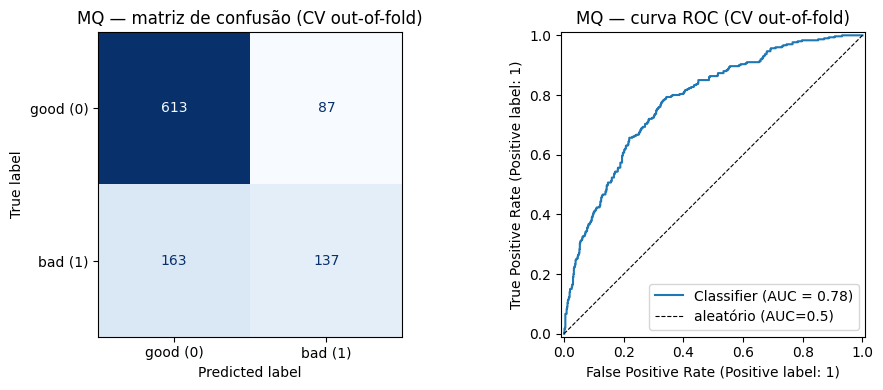

Figura salva em: C:\Users\DELL\Documents\GitHub\PatternRecognition\documents\trabalho3\figures\mq_cv_confusion_roc.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y, y_pred_cv, labels=[0, 1]),
    display_labels=["good (0)", "bad (1)"],
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("MQ — matriz de confusão (CV out-of-fold)")

RocCurveDisplay.from_predictions(y, y_score_cv, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="aleatório (AUC=0.5)")
axes[1].set_title("MQ — curva ROC (CV out-of-fold)")
axes[1].legend(loc="lower right")

fig.tight_layout()
fig_mq = FIG_DIR / "mq_cv_confusion_roc.png"
fig.savefig(fig_mq, dpi=150)
plt.show()
print(f"Figura salva em: {fig_mq}")


## 15 — Síntese do classificador MQ

Resultados da validação cruzada estratificada ($k=5$) com pré-processamento one-hot + padronização numérica embutido no `Pipeline`.

**Observações:**

- A **acurácia** tende a ser alta (~75%) porque a classe *good* é majoritária; por isso também reportamos **precisão**, **revocação**, **F1** e **AUC**.
- Para crédito, falsos negativos (FN: *bad* classificado como *good*) são mais graves segundo a matriz de custos do `german.doc` (custo 5 vs 1).

As seções **16** em diante aplicam **kNN** e **MLP** com a mesma metodologia.


In [18]:
print("=== MQ — validação cruzada k=5 ===")
for _, row in metrics_summary.iterrows():
    print(f"{row['métrica']:22s}: {row['média']:.4f}  ±  {row['desvio padrão']:.4f}")

pe = 1.0 - cv_results["test_accuracy"].mean()
print(f"\nProbabilidade de erro média (1 - acurácia): {pe:.4f}")


=== MQ — validação cruzada k=5 ===
Acurácia              : 0.7500  ±  0.0164
Precisão              : 0.6119  ±  0.0377
Revocação (Recall)    : 0.4567  ±  0.0309
F1-score              : 0.5228  ±  0.0321
AUC-ROC               : 0.7816  ±  0.0161

Probabilidade de erro média (1 - acurácia): 0.2500


## 16 — Vizinho mais Próximo (kNN)

No **Trabalho 1** já utilizamos `KNeighborsClassifier` com $k=5$ em dados 2D. Aqui aplicamos o mesmo princípio ao German Credit: a classe é decidida por **votação majoritária** entre os $k$ vizinhos mais próximos no espaço pré-processado.

**Pré-processamento:** padronização das variáveis numéricas é essencial para distâncias euclidianas (one-hot nas categóricas).


In [19]:
from sklearn.neighbors import KNeighborsClassifier

KNN_NEIGHBORS = 5

preprocessor_knn = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_COLS),
        ("num", StandardScaler(), NUMERIC_COLS),
    ],
    verbose_feature_names_out=False,
)

pipeline_knn = Pipeline([
    ("prep", preprocessor_knn),
    ("clf", KNeighborsClassifier(n_neighbors=KNN_NEIGHBORS)),
])

print(f"Pipeline kNN montado (k={KNN_NEIGHBORS}):", [s[0] for s in pipeline_knn.steps])


Pipeline kNN montado (k=5): ['prep', 'clf']


## 17 — Avaliação kNN (validação cruzada)


In [20]:
cv_results_knn = cross_validate(
    pipeline_knn, X_raw, y, cv=cv, scoring=scoring, return_train_score=False,
)

metrics_summary_knn = pd.DataFrame({
    "métrica": ["Acurácia", "Precisão", "Revocação (Recall)", "F1-score", "AUC-ROC"],
    "média": [
        cv_results_knn["test_accuracy"].mean(),
        cv_results_knn["test_precision"].mean(),
        cv_results_knn["test_recall"].mean(),
        cv_results_knn["test_f1"].mean(),
        cv_results_knn["test_roc_auc"].mean(),
    ],
    "desvio padrão": [
        cv_results_knn["test_accuracy"].std(),
        cv_results_knn["test_precision"].std(),
        cv_results_knn["test_recall"].std(),
        cv_results_knn["test_f1"].std(),
        cv_results_knn["test_roc_auc"].std(),
    ],
})
metrics_summary_knn["média"] = metrics_summary_knn["média"].round(4)
metrics_summary_knn["desvio padrão"] = metrics_summary_knn["desvio padrão"].round(4)
metrics_summary_knn


,métrica,média,desvio padrão
0,Acurácia,0.7370,0.0398
1,Precisão,0.6133,0.1202
2,Revocação (Recall),0.3433,0.0727
3,F1-score,0.4382,0.0873
4,AUC-ROC,0.7096,0.0289


## 18 — Matriz de confusão e curva ROC (kNN)


In [21]:
y_pred_knn = cross_val_predict(pipeline_knn, X_raw, y, cv=cv, method="predict")
y_proba_knn = cross_val_predict(pipeline_knn, X_raw, y, cv=cv, method="predict_proba")[:, 1]

print(classification_report(y, y_pred_knn, target_names=["good (0)", "bad (1)"]))

cm_knn = confusion_matrix(y, y_pred_knn, labels=[0, 1])
print("Matriz de confusão (agregada, out-of-fold):")
print("                 Predito")
print("                 good  bad")
print(f"Real good (0)    {cm_knn[0,0]:4d}  {cm_knn[0,1]:4d}")
print(f"Real bad  (1)    {cm_knn[1,0]:4d}  {cm_knn[1,1]:4d}")


              precision    recall  f1-score   support

    good (0)       0.76      0.91      0.83       700
     bad (1)       0.61      0.34      0.44       300

    accuracy                           0.74      1000
   macro avg       0.69      0.62      0.63      1000
weighted avg       0.72      0.74      0.71      1000

Matriz de confusão (agregada, out-of-fold):
                 Predito
                 good  bad
Real good (0)     634    66
Real bad  (1)     197   103


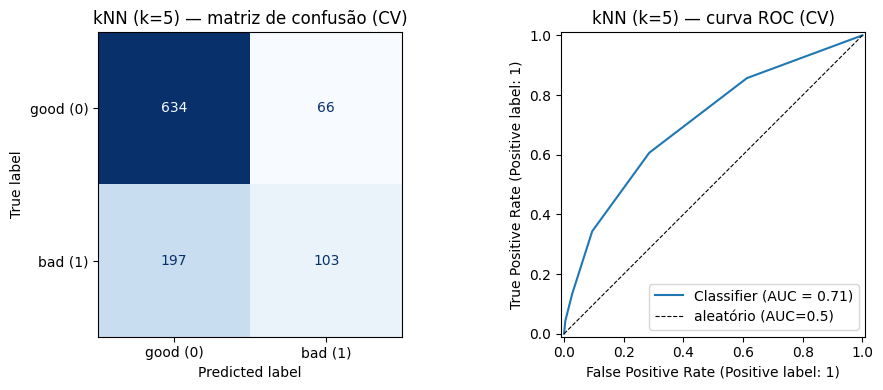

Figura salva em: C:\Users\DELL\Documents\GitHub\PatternRecognition\documents\trabalho3\figures\knn_cv_confusion_roc.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(cm_knn, display_labels=["good (0)", "bad (1)"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False,
)
axes[0].set_title(f"kNN (k={KNN_NEIGHBORS}) — matriz de confusão (CV)")

RocCurveDisplay.from_predictions(y, y_proba_knn, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="aleatório (AUC=0.5)")
axes[1].set_title(f"kNN (k={KNN_NEIGHBORS}) — curva ROC (CV)")
axes[1].legend(loc="lower right")

fig.tight_layout()
fig_knn = FIG_DIR / "knn_cv_confusion_roc.png"
fig.savefig(fig_knn, dpi=150)
plt.show()
print(f"Figura salva em: {fig_knn}")


## 19 — Síntese do classificador kNN

O kNN depende de **distâncias** no espaço de features; com one-hot e padronização numérica, os resultados refletem a estrutura local dos dados de crédito.


In [23]:
print(f"=== kNN — validação cruzada k={CV_FOLDS}, vizinhos={KNN_NEIGHBORS} ===")
for _, row in metrics_summary_knn.iterrows():
    print(f"{row['métrica']:22s}: {row['média']:.4f}  ±  {row['desvio padrão']:.4f}")


=== kNN — validação cruzada k=5, vizinhos=5 ===
Acurácia              : 0.7370  ±  0.0398
Precisão              : 0.6133  ±  0.1202
Revocação (Recall)    : 0.3433  ±  0.0727
F1-score              : 0.4382  ±  0.0873
AUC-ROC               : 0.7096  ±  0.0289


## 20 — Rede MLP (Perceptron Multicamadas)

A **Rede MLP** é um classificador **não linear** com camadas ocultas e função de ativação não linear (ReLU). No `sklearn`, usamos `MLPClassifier` com retropropagação (solver `adam`).

**Pré-processamento:** como no kNN e SVM, a padronização das variáveis numéricas estabiliza o treino por gradiente. Usamos uma rede com **duas camadas ocultas** $(64, 32)$ neurônios — arquitetura modesta, adequada a $n \approx 1000$ instâncias e ~61 features após one-hot.


In [24]:
from sklearn.neural_network import MLPClassifier

MLP_HIDDEN_LAYERS = (64, 32)

preprocessor_mlp = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_COLS),
        ("num", StandardScaler(), NUMERIC_COLS),
    ],
    verbose_feature_names_out=False,
)

pipeline_mlp = Pipeline([
    ("prep", preprocessor_mlp),
    ("clf", MLPClassifier(
        hidden_layer_sizes=MLP_HIDDEN_LAYERS,
        activation="relu",
        solver="adam",
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=RANDOM_STATE,
    )),
])

print(f"Pipeline MLP montado {MLP_HIDDEN_LAYERS}:", [s[0] for s in pipeline_mlp.steps])


Pipeline MLP montado (64, 32): ['prep', 'clf']


## 21 — Avaliação MLP (validação cruzada)

Mesmo esquema de CV e métricas. Para ROC usamos `predict_proba`. O treino ocorre **dentro de cada fold** (sem vazamento).


In [25]:
cv_results_mlp = cross_validate(
    pipeline_mlp, X_raw, y, cv=cv, scoring=scoring, return_train_score=False,
)

metrics_summary_mlp = pd.DataFrame({
    "métrica": ["Acurácia", "Precisão", "Revocação (Recall)", "F1-score", "AUC-ROC"],
    "média": [
        cv_results_mlp["test_accuracy"].mean(),
        cv_results_mlp["test_precision"].mean(),
        cv_results_mlp["test_recall"].mean(),
        cv_results_mlp["test_f1"].mean(),
        cv_results_mlp["test_roc_auc"].mean(),
    ],
    "desvio padrão": [
        cv_results_mlp["test_accuracy"].std(),
        cv_results_mlp["test_precision"].std(),
        cv_results_mlp["test_recall"].std(),
        cv_results_mlp["test_f1"].std(),
        cv_results_mlp["test_roc_auc"].std(),
    ],
})
metrics_summary_mlp["média"] = metrics_summary_mlp["média"].round(4)
metrics_summary_mlp["desvio padrão"] = metrics_summary_mlp["desvio padrão"].round(4)
metrics_summary_mlp


C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,métrica,média,desvio padrão
0,Acurácia,0.7180,0.0150
1,Precisão,0.4163,0.3415
2,Revocação (Recall),0.1100,0.0923
3,F1-score,0.1730,0.1434
4,AUC-ROC,0.6885,0.0761


## 22 — Matriz de confusão e curva ROC (MLP)


In [26]:
y_pred_mlp = cross_val_predict(pipeline_mlp, X_raw, y, cv=cv, method="predict")
y_proba_mlp = cross_val_predict(pipeline_mlp, X_raw, y, cv=cv, method="predict_proba")[:, 1]

print(classification_report(y, y_pred_mlp, target_names=["good (0)", "bad (1)"]))

cm_mlp = confusion_matrix(y, y_pred_mlp, labels=[0, 1])
print("Matriz de confusão (agregada, out-of-fold):")
print("                 Predito")
print("                 good  bad")
print(f"Real good (0)    {cm_mlp[0,0]:4d}  {cm_mlp[0,1]:4d}")
print(f"Real bad  (1)    {cm_mlp[1,0]:4d}  {cm_mlp[1,1]:4d}")


              precision    recall  f1-score   support

    good (0)       0.72      0.98      0.83       700
     bad (1)       0.69      0.11      0.19       300

    accuracy                           0.72      1000
   macro avg       0.70      0.54      0.51      1000
weighted avg       0.71      0.72      0.64      1000

Matriz de confusão (agregada, out-of-fold):
                 Predito
                 good  bad
Real good (0)     685    15
Real bad  (1)     267    33


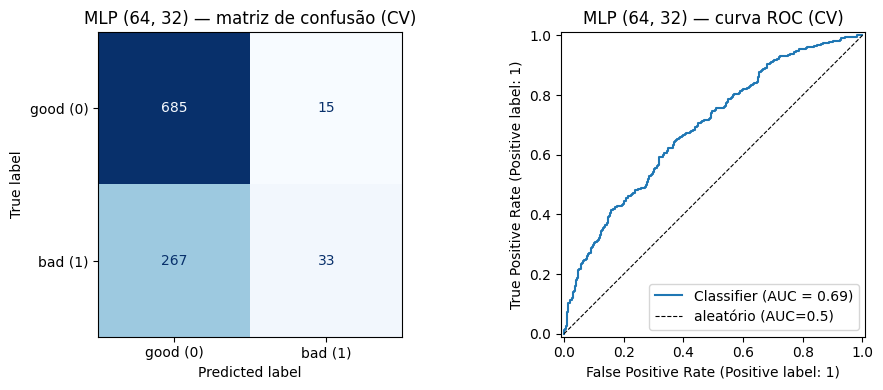

Figura salva em: C:\Users\DELL\Documents\GitHub\PatternRecognition\documents\trabalho3\figures\mlp_cv_confusion_roc.png


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(cm_mlp, display_labels=["good (0)", "bad (1)"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False,
)
axes[0].set_title(f"MLP {MLP_HIDDEN_LAYERS} — matriz de confusão (CV)")

RocCurveDisplay.from_predictions(y, y_proba_mlp, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="aleatório (AUC=0.5)")
axes[1].set_title(f"MLP {MLP_HIDDEN_LAYERS} — curva ROC (CV)")
axes[1].legend(loc="lower right")

fig.tight_layout()
fig_mlp = FIG_DIR / "mlp_cv_confusion_roc.png"
fig.savefig(fig_mlp, dpi=150)
plt.show()
print(f"Figura salva em: {fig_mlp}")


## 23 — Comparação MQ vs kNN vs MLP


In [28]:
comparison_all = pd.DataFrame({
    "métrica": metrics_summary["métrica"],
    "MQ (média)": metrics_summary["média"].values,
    "kNN (média)": metrics_summary_knn["média"].values,
    "MLP (média)": metrics_summary_mlp["média"].values,
})
comparison_all


,métrica,MQ (média),kNN (média),MLP (média)
0,Acurácia,0.7500,0.7370,0.7180
1,Precisão,0.6119,0.6133,0.4163
2,Revocação (Recall),0.4567,0.3433,0.1100
3,F1-score,0.5228,0.4382,0.1730
4,AUC-ROC,0.7816,0.7096,0.6885


In [29]:
print(f"=== MLP — validação cruzada k={CV_FOLDS}, camadas={MLP_HIDDEN_LAYERS} ===")
for _, row in metrics_summary_mlp.iterrows():
    print(f"{row['métrica']:22s}: {row['média']:.4f}  ±  {row['desvio padrão']:.4f}")

pe_mlp = 1.0 - cv_results_mlp["test_accuracy"].mean()
print(f"\nProbabilidade de erro média (1 - acurácia): {pe_mlp:.4f}")


=== MLP — validação cruzada k=5, camadas=(64, 32) ===
Acurácia              : 0.7180  ±  0.0150
Precisão              : 0.4163  ±  0.3415
Revocação (Recall)    : 0.1100  ±  0.0923
F1-score              : 0.1730  ±  0.1434
AUC-ROC               : 0.6885  ±  0.0761

Probabilidade de erro média (1 - acurácia): 0.2820
